# EE446 - TinyML - Assignment 2

## Importing Libraries

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [25]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [26]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [27]:
data = data.drop(["land", "urgent", "numfailedlogins", "numoutboundcmds"], axis=1)
print(f"Shape after dropping columns: {data.shape}")

Shape after dropping columns: (125973, 39)


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [28]:
data["attack"] = data["attack"].apply(lambda x: "normal" if x == "normal" else "attack")
print(data["attack"].value_counts())

attack
normal    67343
attack    58630
Name: count, dtype: int64


In [29]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [30]:
le = LabelEncoder()
for col in ["protocoltype", "service", "flag", "attack"]:
    data[col] = le.fit_transform(data[col])
print(data.dtypes)

duration                    int64
protocoltype                int64
service                     int64
flag                        int64
srcbytes                    int64
dstbytes                    int64
wrongfragment               int64
hot                         int64
loggedin                    int64
numcompromised              int64
rootshell                   int64
suattempted                 int64
numroot                     int64
numfilecreations            int64
numshells                   int64
numaccessfiles              int64
ishostlogin                 int64
isguestlogin                int64
count                       int64
srvcount                    int64
serrorrate                float64
srvserrorrate             float64
rerrorrate                float64
srvrerrorrate             float64
samesrvrate               float64
diffsrvrate               float64
srvdiffhostrate           float64
dsthostcount                int64
dsthostsrvcount             int64
dsthostsamesrv

In [31]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [32]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

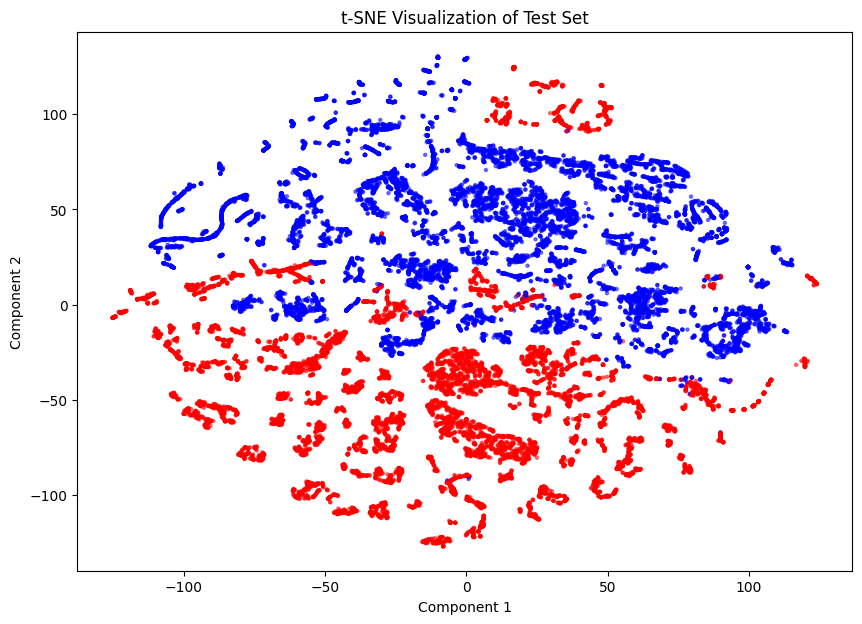

In [33]:
from sklearn.manifold import TSNE

# Apply TSNE to reduce X_test to 2D
tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# Plot: attack (0) = red, normal (1) = blue
plt.figure(figsize=(10, 7))
colors = ["red" if label == 0 else "blue" for label in y_test.flatten()]
plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=colors, alpha=0.5, s=5)
plt.title("t-SNE Visualization of Test Set")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

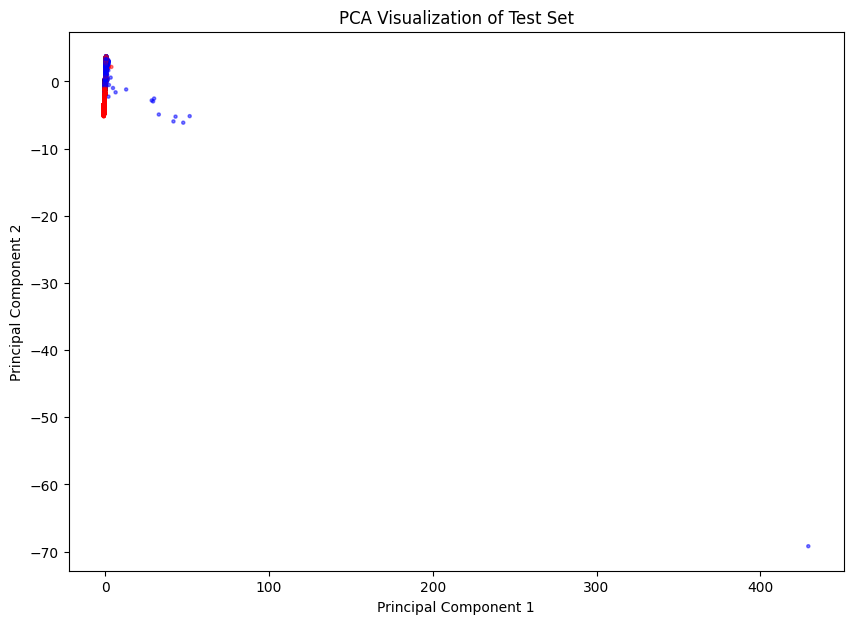

In [34]:
from sklearn.decomposition import PCA

# Apply PCA to reduce X_test to 2D
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Plot: attack (0) = red, normal (1) = blue
plt.figure(figsize=(10, 7))
colors = ["red" if label == 0 else "blue" for label in y_test.flatten()]
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=colors, alpha=0.5, s=5)
plt.title("PCA Visualization of Test Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

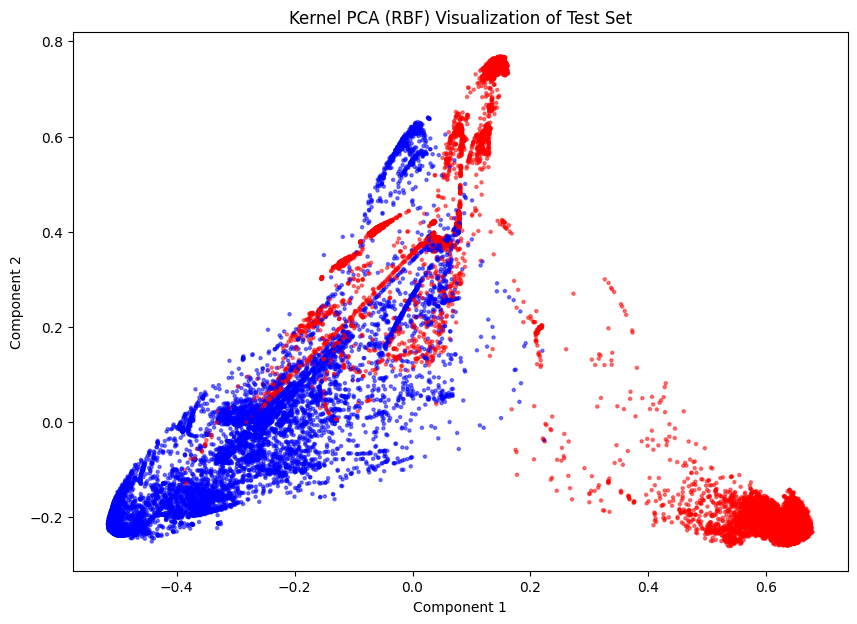

In [35]:
from sklearn.decomposition import KernelPCA

# Apply KernelPCA with rbf kernel to reduce X_test to 2D
kpca = KernelPCA(n_components=2, kernel="rbf")
X_test_kpca = kpca.fit_transform(X_test)

# Plot: attack (0) = red, normal (1) = blue
plt.figure(figsize=(10, 7))
colors = ["red" if label == 0 else "blue" for label in y_test.flatten()]
plt.scatter(X_test_kpca[:, 0], X_test_kpca[:, 1], c=colors, alpha=0.5, s=5)
plt.title("Kernel PCA (RBF) Visualization of Test Set")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [40]:
# Define the DNN model
base_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2, activation="softmax")
])
base_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                2496      
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                                 
Total params: 5138 (20.07 KB)
Trainable params: 5138 (20.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [41]:
# Compile the model
base_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

# Train the model
history = base_model.fit(X_train, y_train,
                         epochs=20,
                         batch_size=64,
                         validation_split=0.1,
                         verbose=1)

Epoch 1/20
1418/1418 [==============================] - 3s 2ms/step - loss: 0.0304 - accuracy: 0.9904 - val_loss: 0.0122 - val_accuracy: 0.9959
Epoch 2/20
1418/1418 [==============================] - 2s 1ms/step - loss: 0.0103 - accuracy: 0.9967 - val_loss: 0.0176 - val_accuracy: 0.9968
Epoch 3/20
1418/1418 [==============================] - 2s 2ms/step - loss: 0.0070 - accuracy: 0.9974 - val_loss: 0.0082 - val_accuracy: 0.9972
Epoch 4/20
1418/1418 [==============================] - 2s 2ms/step - loss: 0.0054 - accuracy: 0.9979 - val_loss: 0.0073 - val_accuracy: 0.9978
Epoch 5/20
1418/1418 [==============================] - 2s 2ms/step - loss: 0.0049 - accuracy: 0.9984 - val_loss: 0.0066 - val_accuracy: 0.9975
Epoch 6/20
1418/1418 [==============================] - 2s 2ms/step - loss: 0.0045 - accuracy: 0.9983 - val_loss: 0.0067 - val_accuracy: 0.9982
Epoch 7/20
1418/1418 [==============================] - 2s 2ms/step - loss: 0.0037 - accuracy: 0.9987 - val_loss: 0.0064 - val_accuracy:

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 1s 1ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11787
           1       1.00      1.00      1.00     13408

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



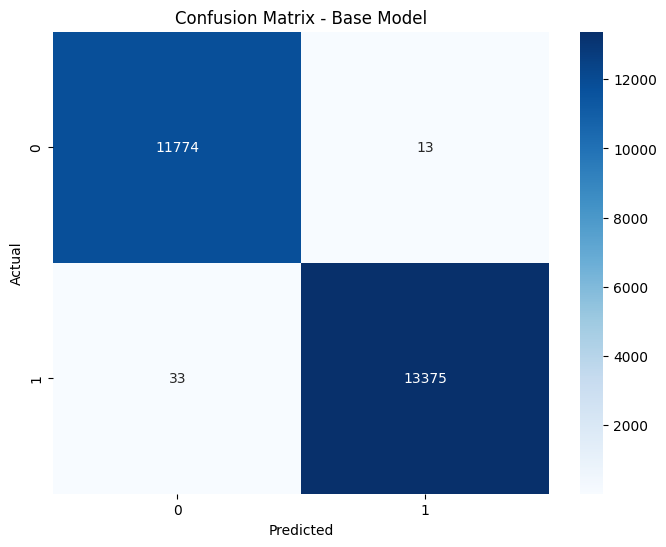

In [42]:
# Get predictions on test set
y_pred_probs = base_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Base Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [44]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Implement Dynamic Range Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

print(f"Quantized model size: {len(tflite_quant_model)} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpxe4h28ms/assets


INFO:tensorflow:Assets written to: /tmp/tmpxe4h28ms/assets


Quantized model size: 9824 bytes


2026-05-06 16:14:33.453354: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-06 16:14:33.454084: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-06 16:14:33.456305: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxe4h28ms
2026-05-06 16:14:33.457516: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-06 16:14:33.457531: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpxe4h28ms
2026-05-06 16:14:33.462757: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-06 16:14:33.503893: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpxe4h28ms
2026-05-06 16:14:33.514157: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 57546 m

In [45]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.09 KB
Quantized model size: 9.59 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report (Quantized Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11787
           1       1.00      1.00      1.00     13408

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



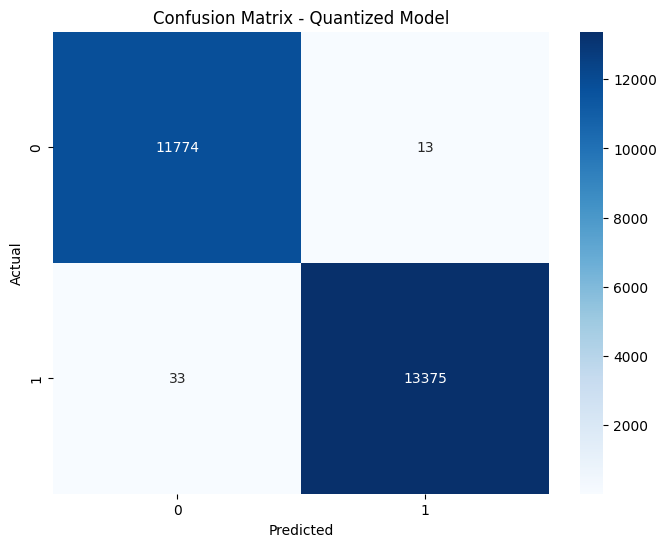

In [46]:
# Load quantized model into interpreter
interpreter_tflite = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter_tflite.allocate_tensors()

# Get input and output details
input_details = interpreter_tflite.get_input_details()
output_details = interpreter_tflite.get_output_details()

# Run inference on each test sample
y_pred_quant = []
for i in range(len(X_test)):
    input_data = np.array([X_test[i]], dtype=np.float32)
    interpreter_tflite.set_tensor(input_details[0]["index"], input_data)
    interpreter_tflite.invoke()
    output_data = interpreter_tflite.get_tensor(output_details[0]["index"])
    y_pred_quant.append(np.argmax(output_data))

y_pred_quant = np.array(y_pred_quant)

# Classification Report
print("Classification Report (Quantized Model):")
print(classification_report(y_test, y_pred_quant))

# Confusion Matrix
cm_quant = confusion_matrix(y_test, y_pred_quant)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_quant, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Quantized Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Converting tflite_model to C and create the header file

In [47]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [48]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [56]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[5:15,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.1094813229699167, -0.12470615670462065, 1.3931828317609012, 
    0.7511112872365361, -0.007623747152777872, -0.00483682909271775, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    10.022263152053373, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.3405754870548312, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 3.4741184775599305, 
    0.7343425609306344, 0.2289653843949096, 0.06405715615320443, 
    -0.12148518423158469, -0.4801968475158174, -0.28910340026287856, 
    -0.5945660854813608, -0.5799942796747285, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.110249223212498

In [55]:
ytest=y_test[5:15]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[10][1] = {
    1, 0, 0, 1, 0, 0, 1, 1, 0, 0
};



In [57]:
# Non-quantized conversion (for Arduino deployment testing)
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
# No converter.optimizations line
tflite_float_model = converter.convert()

# Generate the header file from this model instead
hex_array = [format(val, '#04x') for val in tflite_float_model]
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
header_str = c_writer.create_header(c_model, "network_model")

with open('network_model.h', 'w') as file:
    file.write(header_str)

INFO:tensorflow:Assets written to: /tmp/tmp_wsuh_vf/assets


INFO:tensorflow:Assets written to: /tmp/tmp_wsuh_vf/assets
2026-05-06 16:33:19.277574: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-06 16:33:19.277764: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-06 16:33:19.279751: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_wsuh_vf
2026-05-06 16:33:19.284126: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-06 16:33:19.284179: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_wsuh_vf
2026-05-06 16:33:19.293891: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-06 16:33:19.352247: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_wsuh_vf
2026-05-06 16:33:19.361354: I tensorflow/cc/saved_model/loader.cc:316] SavedModel